## Wave-guiding Physics in FDTD - 3 : Plasmonics

In this notebook, we shall revisit the waveguiding problem but now through plasmonics.

Consider a dielectric ($\epsilon_d$) -metal ($\epsilon_m$) interface. It can be shown that the wavenumber for a propagation wave along this interface is given by:

## $\beta_{sp} = k_0\sqrt{\frac{\epsilon_m\epsilon_d}{\epsilon_m+\epsilon_d}}$

where the dispersion of the metal $\epsilon_m$ is given by:
## $\epsilon_m = \epsilon_{\infty} - \sum_n \frac{\omega_n^2}{\omega^2 - \omega_n^2 - i\gamma_n \omega}$

We can create such a Drude dispersion in meep. This will allow us to better appreciate the dispersion relation $\beta_{sp}$

In [1]:
from meep.materials import Au
import numpy as np
import meep as mp
import matplotlib.pyplot as plt

Using MPI version 4.1, 1 processes


In [2]:
def eps_lorentzian(freqs,eps_inf,wp,sigma,gamma):
    """
    custom function for epsilon that fits meep's dispersion implementation.
    """
    w = freqs
    eps = eps_inf + (sigma*wp**2)/(wp**2 - w**2 - 1j*w*gamma )
    return eps

def beta_sp(freqs,eps_metal, eps_dielectric):
    """
    For a given frequency and a dielectric | metal interface, calculate the wavenumber beta allowed for surface plasmons
    """
    if type(eps_dielectric)==float:
        eps_dielectric = eps_dielectric * np.ones(eps_metal.shape[0])
    beta = (freqs)* np.sqrt((eps_metal * eps_dielectric)/(eps_metal + eps_dielectric))
    return beta

We extract the plasma frequency of the first oscillator

In [13]:
omega_p = np.sqrt( (Au.E_susceptibilities[0].sigma_diag[0]) *(Au.E_susceptibilities[0].frequency)**2)

Actual Gold has many dispersions each with its own characteristic frequency, strength and loss

In [10]:
Au.E_susceptibilities

We use the first Drude susceptibility to create a new material. This way, we can focus on purely the drude model.

In [4]:
au_susc = [
    mp.LorentzianSusceptibility(frequency=Au.E_susceptibilities[0].frequency, gamma=Au.E_susceptibilities[0].gamma, sigma=Au.E_susceptibilities[0].sigma_diag[0]),
]

# Material definition 
Au_new = mp.Medium(epsilon=1.0, E_susceptibilities=au_susc, valid_freq_range=mp.FreqRange(min=1/1.5, max=1 / 0.1)
)

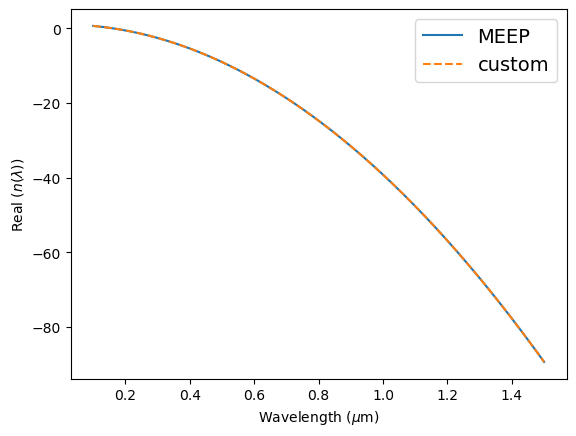

In [10]:
wvl = np.linspace(0.1,1.5,500)
freqs=1/wvl
aufit = eps_lorentzian(freqs = freqs,
                       eps_inf=1,
                       wp = Au.E_susceptibilities[0].frequency,
                       sigma = Au.E_susceptibilities[0].sigma_diag[0], 
                       gamma = Au.E_susceptibilities[0].gamma)

Au_ = []
for i in range(wvl.shape[0]):
    Au_.append(Au_new.epsilon(freqs[i])[0,0])

plt.plot(wvl,np.real(np.array(Au_)),label='MEEP')
plt.plot(wvl,np.real(aufit),'--',label='custom')
plt.xlabel('Wavelength ($\\mu$m)')
plt.ylabel('Real ($n(\lambda)$)')
plt.legend(fontsize=14)

Now we can use our function `beta_sp()` defined above for air and the new defined metal to plot the dispersion relation $\beta(\omega)$.

(0.0, 15.0)

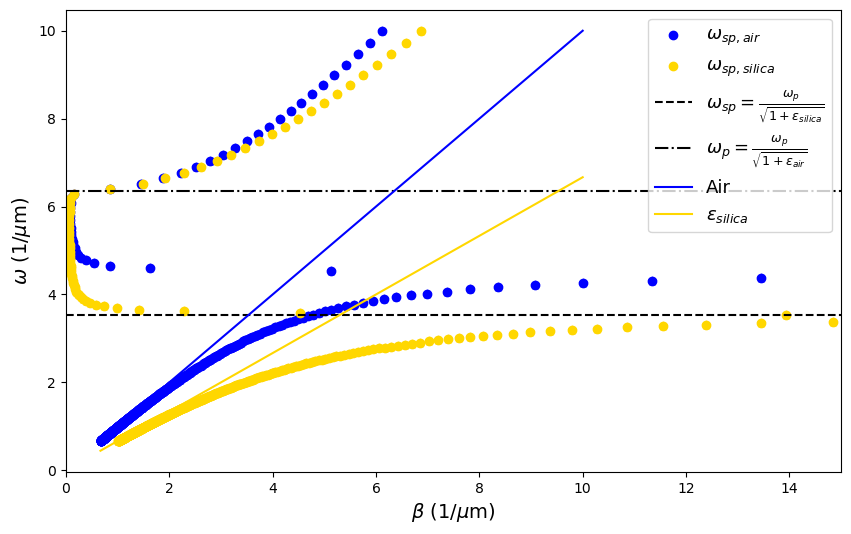

In [ ]:
eps_dielectric = 2.25


plt.figure(figsize=(10,6))
plt.scatter(np.real(beta_sp(freqs,aufit,1))[:] , freqs[:], color='blue',marker='o',label='$\omega_{sp,air}$')
plt.scatter(np.real(beta_sp(freqs,aufit,1))[:] , freqs[:], color='blue',marker='*')
plt.scatter(np.real(beta_sp(freqs,aufit,2.25))[:] , freqs[:], color='gold',label='$\omega_{sp,silica}$')
plt.scatter(np.real(beta_sp(freqs,aufit,2.25))[:] , freqs[:], color='gold',marker='*')

#plt.scatter(np.real(beta_sp(freqs,np.array(Au_),1)),freqs,color='pink')

plt.axhline(y=omega_p/np.sqrt(1+eps_dielectric),linestyle='--',color='black',label='$\omega_{sp}=\\frac{\omega_p}{\sqrt{1+\epsilon_{silica}}}$')

plt.axhline(y=omega_p,linestyle='dashdot',color='black',label='$\omega_{p}=\\frac{\omega_p}{\sqrt{1+\epsilon_{air}}}$')
plt.plot(freqs,freqs,label='Air',color='blue')
plt.plot(freqs,freqs/1.5,label='$\epsilon_{silica}$',color='gold')
plt.legend(fontsize=13)
plt.xlabel('$\\beta$ ($1/\\mu$m)',fontsize=14)
plt.ylabel('$\omega$ ($1/\\mu$m)',fontsize=14)
plt.xlim(0,15)


In [40]:
beta = beta_sp(freqs,eps_metal=aufit,eps_dielectric=1)

### The surface plasmon frequency approaches the asymptotic value of $\omega_{sp} = \frac{\omega_p}{\sqrt{1+\epsilon_d}}$. This gives us the upper-bound on the $\omega$ (and lower bound on $\lambda$) that we can use in our simulations for which surface plasmons get be excited ($\omega < \omega_{sp}$).

In [17]:
omega_sp = omega_p / np.sqrt(1 + 1)
print (omega_sp)

4.489657681347318


Since the dispersion for surface plasmons is below the light-line, to excite it, we here use a grating.

In [24]:
resolution = 100   # pixels/um

sy = 3      # size of cell in y direction (perpendicular to wvg.)
pad = 0.6           # padding between last hole and PML edge
dpml = 0.6         # PML thickness

sx = 0.7*3 
cell = mp.Vector3(sx,sy,0)
pml_layers = [mp.PML(dpml,direction=mp.Y)]


In [25]:
f_min = 1/1
f_max = 1/0.2
fcen = 0.5*(f_min + f_max)
df = f_max - f_min    # pulse frequency width

src = [mp.Source(mp.GaussianSource(fcen, fwidth=df,is_integrated=True),
                     component=mp.Hz,
                     center=mp.Vector3(y=0.5*sy-dpml),
                     size=mp.Vector3(sx,0))]

<Axes: xlabel='X', ylabel='Y'>

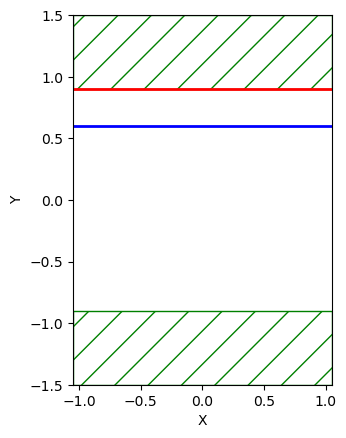

In [ ]:
sim = mp.Simulation(cell_size=cell,
                        boundary_layers=pml_layers,
                        sources=src,
                        resolution=resolution)
freg = mp.FluxRegion(center=mp.Vector3(y=0.5*sy-dpml-0.3),
                         size=mp.Vector3(x=sx ))
nfreq = 200 # number of frequencies at which to compute flux

refl = sim.add_flux(fcen, df, nfreq, freg)
sim.plot2D()


In [27]:

sim.run(#mp.at_every(5,animate),
        until_after_sources=mp.stop_when_fields_decayed(50, mp.Hz, mp.Vector3(y=0.5*sy-dpml-0.5), 1e-3),
)


wvl = 1/np.array(mp.get_flux_freqs(refl))
t0 = mp.get_fluxes(refl)

refl_data = sim.get_flux_data(refl)
sim.reset_meep()

-----------
Initializing structure...
time for choose_chunkdivision = 0.00126273 s
Working in 2D dimensions.
Computational cell is 2.1 x 3 x 0 with resolution 100
time for set_epsilon = 0.108987 s
-----------
on time step 8217 (time=41.085), 0.000486851 s/step
field decay(t = 50.005): 0.24680733747875291 / 0.24680733747875291 = 1.0
on time step 15526 (time=77.63), 0.000547306 s/step
field decay(t = 100.01): 6.853643233191684e-07 / 0.24680733747875291 = 2.7769203716569807e-06
run 0 finished at t = 100.01 (20002 timesteps)


     block, center = (0,-0.75,0)
          size (1e+20,1.5,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)
     block, center = (-0.7,0.07,0)
          size (0.21,0.14,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (2.25,2.25,2.25)
     block, center = (0,0.07,0)


          size (0.21,0.14,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (2.25,2.25,2.25)
     block, center = (0.7,0.07,0)
          size (0.21,0.14,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (2.25,2.25,2.25)


<Axes: xlabel='X', ylabel='Y'>

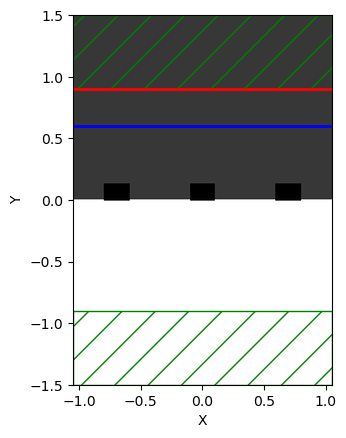

In [28]:
sim.reset_meep()
eps = 2.25        # dielectric constant of waveguide
geometry = [mp.Block(size=mp.Vector3(mp.inf,0.5*sy,mp.inf), center=mp.Vector3(0,-0.25*sy),material=Au_new)] #mp.Medium(epsilon=eps))]

pitch = sx/3
gratx,graty=0.3*pitch, 0.2*pitch

geometry.append(mp.Block(size=mp.Vector3(gratx,graty,mp.inf), center=mp.Vector3(-pitch,0.5*graty),material=mp.Medium(epsilon=eps)))
geometry.append(mp.Block(size=mp.Vector3(gratx,graty,mp.inf), center=mp.Vector3(0,0.5*graty),material=mp.Medium(epsilon=eps)))
geometry.append(mp.Block(size=mp.Vector3(gratx,graty,mp.inf), center=mp.Vector3(pitch,0.5*graty),material=mp.Medium(epsilon=eps)))

pml_layers = [mp.PML(thickness=dpml,direction=mp.Y,side=mp.High),
                  mp.Absorber(thickness=dpml,direction=mp.Y,side=mp.Low)]

sim = mp.Simulation(cell_size=cell,
                        geometry=geometry,
                        boundary_layers=pml_layers,
                        sources=src,
                        resolution=resolution)

    # transmitted flux
refl = sim.add_flux(fcen, df, nfreq, freg)

sim.plot2D()

In [29]:
from IPython.display import Video

-----------
Initializing structure...
time for choose_chunkdivision = 0.000359616 s
Working in 2D dimensions.
Computational cell is 2.1 x 3 x 0 with resolution 100
     block, center = (0,-0.75,0)
          size (1e+20,1.5,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)
     block, center = (-0.7,0.07,0)
          size (0.21,0.14,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (2.25,2.25,2.25)
     block, center = (0,0.07,0)
          size (0.21,0.14,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (2.25,2.25,2.25)
     block, center = (0.7,0.07,0)
          size (0.21,0.14,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (2.25,2.25,2.25)
time for set_epsilon = 0.198548 s
time for set_conductivity = 0.0060303 s
time for set_conductivity = 0.00515231 s
time for set_conductivity = 0.005925

     block, center = (0,-0.75,0)
          size (1e+20,1.5,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (1,1,1)
     block, center = (-0.7,0.07,0)
          size (0.21,0.14,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (2.25,2.25,2.25)
     block, center = (0,0.07,0)
          size (0.21,0.14,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (2.25,2.25,2.25)
     block, center = (0.7,0.07,0)
          size (0.21,0.14,1e+20)
          axes (1,0,0), (0,1,0), (0,0,1)
          dielectric constant epsilon diagonal = (2.25,2.25,2.25)
field decay(t = 10.005): 0.23875621432227523 / 0.23875621432227523 = 1.0
on time step 3701 (time=18.505), 0.00108082 s/step
field decay(t = 20.01): 0.00033701408732034075 / 0.23875621432227523 = 0.0014115405887003894
field decay(t = 30.015): 1.550305378466776e-05 / 0.23875621432227523 = 6.493256658753017e-05
field

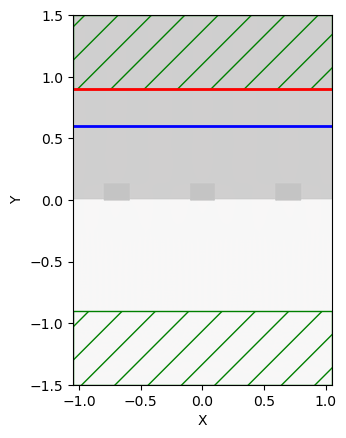

In [30]:
sim.load_minus_flux_data(refl, refl_data)

animate = mp.Animate2D(fields=mp.Hz, realtime=False, normalize=True) #Meep object for animating fields

sim.run(mp.at_every(0.5,animate),
        until_after_sources=mp.stop_when_fields_decayed(10, mp.Hz, mp.Vector3(y=0.5*sy-dpml-0.5), 1e-5),
)

filename = "spr_grating.mp4"
animate.to_mp4(4, filename)
Video(filename) #generates the video and saves it under the given filename

Text(0.5, 0, 'Frequency')

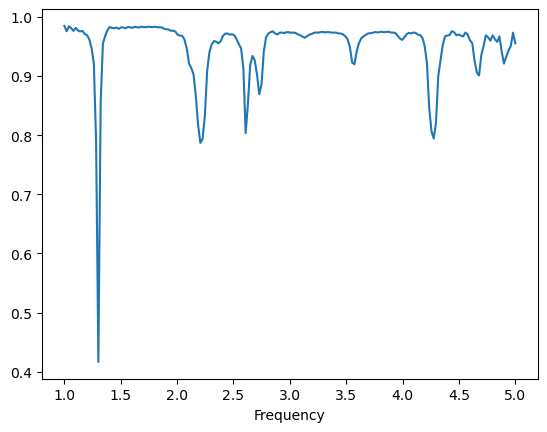

In [43]:
rg= np.array(mp.get_fluxes(refl))
reflectance = -rg/np.array(t0)
plt.plot(1/wvl,reflectance)

plt.xlabel('Frequency')

In [35]:
min_ind = np.argmin(reflectance)
print (1/wvl[min_ind])

1.3015075376884422


The momentum we imparted through the grating is $\beta = 1/\Lambda$. Notice that a factor of $2\pi$ is missing. This is because meep normalizes reciprocal space quantities as simply 1/real space quantities.

In [37]:
beta_grating = 1/pitch
print (beta_grating)

1.4285714285714288


In [42]:
bind= np.argmin(np.abs(beta-beta_grating))
print(beta[bind], 1/wvl[min_ind])

(1.4309597160619019+0.0012299637644514285j) 1.3015075376884422


The peak in the spectrum is well-predicted by our estimate. Please note, since the grating has a finite filling fraction and a non-zero dielectric constant, it will renormalize these peaks by a tiny margin.